<a href="https://colab.research.google.com/github/oxedanda/pml_final_project/blob/main/notebooks/03_future_wine_prediction_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Machine Learning Final Project
# Predicting Annual Wine Production by Viticultural Region in Portugal

This notebook develops the baseline predictive model for the project. It prepares the merged dataset, defines the target and input features, applies a chronological train-test split, and fits a first linear regression model to predict annual wine production by Portuguese viticultural region.

In [1]:
!git clone https://github.com/oxedanda/pml_final_project.git

Cloning into 'pml_final_project'...
remote: Enumerating objects: 139, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 139 (delta 56), reused 52 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (139/139), 1.64 MiB | 8.49 MiB/s, done.
Resolving deltas: 100% (56/56), done.


In [27]:
DATADIR = Path("/content/pml_final_project/data/processed")
FIGURESDIR = Path("/content/pml_final_project/outputs/figures")

FIGURESDIR.mkdir(parents=True, exist_ok=True)

PRODUCTIONFILE = DATADIR / "wine_production_by_region_clean.csv"
AREAFILE = DATADIR / "vineyard_area_by_region_clean.csv"

print("Figures will be saved to:", FIGURESDIR)

Figures will be saved to: /content/pml_final_project/outputs/figures


In [10]:
# Practical Machine Learning Final Project

## Predicting Annual Wine Production by Viticultural Region in Portugal

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [16]:
# File paths
DATA_DIR = Path("/content/pml_final_project/data/processed")


PRODUCTION_FILE = DATA_DIR / "wine_production_by_region_clean.csv"
AREA_FILE = DATA_DIR / "vineyard_area_by_region_clean.csv"


# Load cleaned datasets
production = pd.read_csv(PRODUCTION_FILE)
area = pd.read_csv(AREA_FILE)


# Merge datasets
df = production.merge(
    area,
    on=["region", "year_start"],
    how="left"
)


print("Production shape:", production.shape)
print("Area shape:", area.shape)
print("Merged shape:", df.shape)


display(df.head())

Production shape: (238, 8)
Area shape: (288, 3)
Merged shape: (238, 9)


,region,campaign_year,year_start,total_production_hl,dop_production_hl,igp_production_hl,year_variety_production_hl,non_certified_production_hl,vineyard_area_ha
0,Alentejo,2009/10,2009,810338,356783,449833,995,2728,23490.0
1,Algarve,2009/10,2009,23650,4680,11797,0,7173,1983.0
2,Açores,2009/10,2009,13754,2771,2832,6,8145,1700.0
3,Bairrada,2009/10,2009,246705,69459,64138,1068,112041,NaN
4,Beira Interior,2009/10,2009,192084,50158,20570,14,121342,NaN


In [17]:
# Target variable
target = "total_production_hl"

# Features for the first model
featurecolumns = [
    "region",
    "year_start",
    "vineyard_area_ha",
]

X = df[featurecolumns].copy()
y = df[target].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Features shape: (238, 3)
Target shape: (238,)


,region,year_start,vineyard_area_ha
0,Alentejo,2009,23490.0
1,Algarve,2009,1983.0
2,Açores,2009,1700.0
3,Bairrada,2009,NaN
4,Beira Interior,2009,NaN


,total_production_hl
0,810338
1,23650
2,13754
3,246705
4,192084


In [18]:
# Chronological Split and Preprocessing Pipeline
dfsorted = df.sort_values(["year_start", "region"]).reset_index(drop=True)

X = dfsorted[featurecolumns].copy()
y = dfsorted[target].copy()

# Use the last 3 campaign years as the test set
testyears = sorted(dfsorted["year_start"].unique())[-3:]

traindata = dfsorted[~dfsorted["year_start"].isin(testyears)].copy()
testdata = dfsorted[dfsorted["year_start"].isin(testyears)].copy()

Xtrain = traindata[featurecolumns]
ytrain = traindata[target]
Xtest = testdata[featurecolumns]
ytest = testdata[target]

print("Train shape:", Xtrain.shape)
print("Test shape:", Xtest.shape)
print("Test years:", testyears)

Train shape: (196, 3)
Test shape: (42, 3)
Test years: [np.int64(2023), np.int64(2024), np.int64(2025)]


In [19]:
# Chronological Split and Preprocessing Pipeline
dfsorted = df.sort_values(["year_start", "region"]).reset_index(drop=True)

X = dfsorted[featurecolumns].copy()
y = dfsorted[target].copy()

# Use the last 3 campaign years as the test set
testyears = sorted(dfsorted["year_start"].unique())[-3:]

traindata = dfsorted[~dfsorted["year_start"].isin(testyears)].copy()
testdata = dfsorted[dfsorted["year_start"].isin(testyears)].copy()

Xtrain = traindata[featurecolumns]
ytrain = traindata[target]
Xtest = testdata[featurecolumns]
ytest = testdata[target]

print("Train shape:", Xtrain.shape)
print("Test shape:", Xtest.shape)
print("Test years:", testyears)

# Preprocessing
numericfeatures = ["year_start", "vineyard_area_ha"]
categoricalfeatures = ["region"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numericfeatures),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricalfeatures),
    ]
)

# Baseline model
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", LinearRegression()),
    ]
)

Train shape: (196, 3)
Test shape: (42, 3)
Test years: [np.int64(2023), np.int64(2024), np.int64(2025)]


In [20]:
# Train the Model and Evaluate
model.fit(Xtrain, ytrain)

ypred = model.predict(Xtest)

mae = mean_absolute_error(ytest, ypred)
rmse = np.sqrt(mean_squared_error(ytest, ypred))
r2 = r2_score(ytest, ypred)

print(f"MAE {mae:,.2f}")
print(f"RMSE {rmse:,.2f}")
print(f"R2 {r2:.4f}")

MAE 80,649.69
RMSE 116,422.76
R2 0.9464


In [21]:
# Results
results = Xtest.copy()
results["actual"] = ytest.values
results["predicted"] = ypred
results["error"] = results["actual"] - results["predicted"]

display(results.head(10))

,region,year_start,vineyard_area_ha,actual,predicted,error
196,Alentejo,2023,26443.0,1233148,1.104641e+06,128506.583827
197,Algarve,2023,1355.0,16613,4.204705e+04,-25434.046050
198,Açores,2023,1737.0,8007,3.564560e+04,-27638.595145
199,Bairrada,2023,9440.0,251051,2.613120e+05,-10260.981730
200,Beira Interior,2023,11738.0,185805,2.451646e+05,-59359.630263
201,Douro,2023,44224.0,1561729,1.465986e+06,95743.086973
202,Dão,2023,12898.0,281210,3.085657e+05,-27355.689103
203,Lisboa,2023,17857.0,1539151,1.119030e+06,420121.079571
204,Madeira,2023,669.0,37800,6.767213e+04,-29872.125651
205,P. Setúbal,2023,7417.0,589897,4.948691e+05,95027.943714


In [29]:
from pathlib import Path

FIGURES_DIR = Path("/content/pml_final_project/outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Figures will be saved to:", FIGURES_DIR)

Figures will be saved to: /content/pml_final_project/outputs/figures


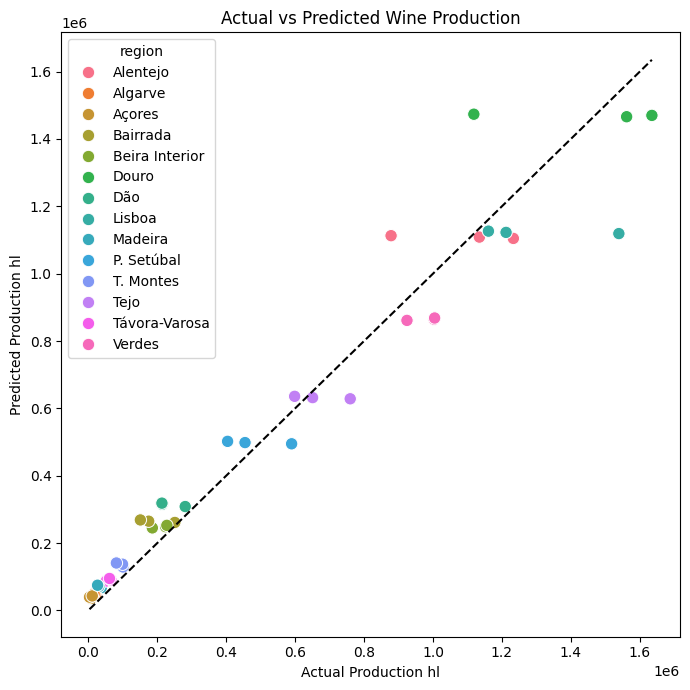

In [28]:
# Actual vs Predicted Plot
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FIGURES_DIR = Path("/content/pml_final_project/outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

results = Xtest.copy()
results["actual"] = ytest.values
results["predicted"] = ypred
results["error"] = results["actual"] - results["predicted"]

plt.figure(figsize=(7, 7))
sns.scatterplot(data=results, x="actual", y="predicted", hue="region", s=80)

minval = min(results["actual"].min(), results["predicted"].min())
maxval = max(results["actual"].max(), results["predicted"].max())

plt.plot([minval, maxval], [minval, maxval], linestyle="--", color="black")
plt.title("Actual vs Predicted Wine Production")
plt.xlabel("Actual Production hl")
plt.ylabel("Predicted Production hl")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "wine_production_simulator.png", dpi=300, bbox_inches="tight")
plt.show()

### Results Interpretation

The baseline linear regression model provides a reasonable first approximation of annual wine production by region.

In several cases, the predicted values are in the same general range as the observed values, which suggests that the selected features capture part of the production pattern.

However, the prediction errors remain noticeable for some regions and years. This is expected because the model uses only three predictors: region, year, and vineyard area.

Wine production is influenced by additional factors such as weather conditions, disease pressure, management practices, and other regional characteristics that are not included in the current dataset.

Overall, this baseline model is useful as a reference point for the project. It establishes a simple and interpretable benchmark that can later be compared with more flexible models or richer feature sets.